# FIP 00 — Fiber photometry exploration with motion energy

Access and plot fiber-photometry (FIP) data, then relate the signals to gross movement
(motion energy). 

- motion energy repo: https://github.com/AllenNeuralDynamics/aind-motion-energy

- ME capsule: https://codeocean.allenneuraldynamics.org/capsule/5856343/tree

- ME batch dispatcher: https://codeocean.allenneuraldynamics.org/capsule/5110154/tree

- Fiber data asset ID: `6babbf3d-6970-4456-aab5-d730ed57c269` (saved parquet hierarchy from
  `save_nwb_list`, loaded with `rachel_analysis_utils.nwb_utils.load_nwb_list`).

**Signal layout:** each row of `df_fip` is one `event` series named `{channel}_{fiber}`
(+ a processed `*_dff` variant). Channels: `G` (green/GCaMP), `R` (red), `Iso` (isosbestic
control); fibers `0`–`4`. `timestamps` are zeroed at the first go cue.

**Flow:** imports → data loading → data processing → data visualization.


## Imports & setup

In [26]:
import os
import glob
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Rachel's lab utilities (installed / mounted in the Code Ocean capsule).
from rachel_analysis_utils import nwb_utils as r_utils

# AIND event-alignment primitive (peri-event windowing). df_fip['timestamps'] and the
# df_trials '*_in_session' columns share one clock: t=0 is the first go cue of the session.
from aind_dynamic_foraging_data_utils import alignment

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)

In [27]:
# load_nwb_list reads the parquet hierarchy with pd.read_parquet(..., engine="fastparquet"),
# which is hardcoded in rachel_analysis_utils. The capsule image doesn't ship fastparquet,
# so install it on first run. (No-op once it's importable.) For a permanent fix, add
# `fastparquet` to the Code Ocean environment instead.
try:
    import fastparquet  # noqa: F401
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "fastparquet"])
    import fastparquet  # noqa: F401
print("fastparquet", fastparquet.__version__)

fastparquet 2024.11.0


## Data loading

`load_nwb_list(plot_loc)` reads a saved parquet hierarchy laid out as
`plot_loc/<subject>/<session>/df_fip.parquet` and returns one `dummy_nwb` per session (each
with `.df_fip`, `.df_trials`, `.df_events`, `.session_id`). Project data is at
`/root/capsule/data/DA_NE_4channels/` (212 sessions); set `RELOCATE=True` to rediscover the
root by glob if the asset layout changes.


In [28]:
# Hardwired to the attached asset's saved parquet hierarchy so we skip the
# recursive glob every session. This is the `plot_loc` root that load_nwb_list
# wants: plot_loc/<subject>/<session>/df_fip.parquet
plot_loc = "/root/capsule/data/DA_NE_4channels/"

assert os.path.isdir(plot_loc), (
    f"{plot_loc} not found. Attach asset 6babbf3d-6970-4456-aab5-d730ed57c269 "
    "(saved parquet hierarchy) to this capsule, or fix the path."
)
print("plot_loc =", plot_loc)

# Fallback: if the layout ever changes, set RELOCATE=True to rediscover by glob.
RELOCATE = False
if RELOCATE:
    fip_files = glob.glob(os.path.join("/root/capsule/data", "**", "df_fip.parquet"), recursive=True)
    plot_locs = sorted({os.path.dirname(os.path.dirname(os.path.dirname(f))) for f in fip_files})
    print(f"{len(fip_files)} session(s) found across {len(plot_locs)} root(s):", plot_locs)

plot_loc = /root/capsule/data/DA_NE_4channels/


In [29]:
nwb_list_raw, df_sess, df_slope = r_utils.load_nwb_list(plot_loc, load_fip=True)

print(f"Loaded {len(nwb_list_raw)} session(s):")
for nwb in nwb_list_raw:
    has_fip = getattr(nwb, "df_fip", None) is not None
    print(f"  {nwb.session_id:<32s} fip={has_fip}")

loading 7 df_sess file(s)
no rpe_slope.csv found at plot location, skipping
loading 808054_2025-09-02
loading 808054_2025-09-03
loading 808054_2025-09-04
loading 808054_2025-09-05
loading 808054_2025-09-08
loading 808054_2025-09-09
loading 808054_2025-09-10
loading 808054_2025-09-11
loading 808054_2025-09-12
loading 808054_2025-09-15
loading 808054_2025-09-16
loading 808054_2025-09-17
loading 808054_2025-09-18
loading 808054_2025-09-19
loading 808054_2025-09-22
loading 808054_2025-09-23
loading 808054_2025-09-24
loading 808054_2025-09-25
loading 808054_2025-09-26
loading 808054_2025-10-02
loading 808054_2025-10-07
loading 808054_2025-10-08
loading 808054_2025-10-10
loading 808054_2025-10-13
loading 808054_2025-10-14
loading 808054_2025-10-15
loading 808054_2025-10-16
loading 808054_2025-10-17
loading 808056_2025-09-12
loading 808056_2025-09-15
loading 808056_2025-09-16
loading 808056_2025-09-17
loading 808056_2025-09-18
loading 808056_2025-09-22
loading 808056_2025-09-23
loading 808056

### Curation

`apply_curation_nwb_list` maps each fiber to its brain region (annotating
`df_fip['intended_measurement']`), renames `df_trials` columns, and drops bad
channels/sessions. Set `USE_CURATION=False` to skip it and label traces by fiber number only.

⚠️ `CURATION_FILE` must match THIS dataset's fiber layout. For DA_NE_4channel use
`..._firstpass` — it carries the `correct_mapping` fiber→region dict. (`..._secondpass` lacks
`correct_mapping`, so `intended_measurement` would come back empty.)


In [30]:
USE_CURATION = True
CURATION_FILE = "DA_NE_4channel_datacuration_firstpass"

if USE_CURATION:
    # Locate the curation JSON inside the installed rachel package, with a /src fallback.
    json_path = None
    try:
        import rachel_analysis_utils
        pkg_dir = os.path.dirname(rachel_analysis_utils.__file__)
        cand = os.path.join(pkg_dir, "data_curation", CURATION_FILE + ".json")
        if os.path.exists(cand):
            json_path = cand
    except Exception:
        pass
    if json_path is None:
        hits = glob.glob("/src/**/data_curation/" + CURATION_FILE + ".json", recursive=True)
        assert hits, "Could not locate " + CURATION_FILE + ".json"
        json_path = hits[0]

    with open(json_path, "r") as fh:
        df_curation = json.load(fh)
    print("Using curation:", json_path)

    nwb_list, nwb_list_curated = r_utils.apply_curation_nwb_list(
        nwb_list_raw, df_curation, drop_borderline=True
    )
    print(f"Curated -> {len(nwb_list)} session(s) kept.")
else:
    nwb_list = nwb_list_raw
    print("No curation applied; using raw nwb_list.")

Using curation: /src/rachel-analysis-utils/src/rachel_analysis_utils/data_curation/DA_NE_4channel_datacuration_firstpass.json
Curated -> 172 session(s) kept.


## Data processing

Everything below works on **one session** (`SESSION_IDX`) and produces the objects the plots
consume: the signal table `meta`, the reusable alignment helpers, the three example signals,
and motion energy on the FIP clock.


### Select a session and build the signal table

`df_fip` is tidy: each `event` (`{channel}_{fiber}[_variant]`) is one trace, `timestamps`
zeroed at the first go cue. We drop `pearsonR` series (signal-signal correlations, not
photometry) and, after curation, attach region labels in `meta['region']`.


In [31]:
SESSION_IDX = 0
nwb = nwb_list[SESSION_IDX]
df_fip = nwb.df_fip
# Assert (don't sort) that each series is already time-ordered, so get_trace slices and
# np.interp downstream are valid. Fails loudly if upstream ever delivers unsorted rows.
assert (df_fip.groupby("event")["timestamps"].diff().dropna() >= 0).all(), \
    "df_fip timestamps not sorted within an event — sort before use"
df_trials = getattr(nwb, "df_trials", None)

# Go-cue times on the df_fip clock (first-go-cue-zeroed) drive every peri-event alignment.
ALIGN_COL = "goCue_start_time_in_session"
assert df_trials is not None and ALIGN_COL in df_trials.columns, (
    f"Need '{ALIGN_COL}' on df_trials (first-go-cue-zeroed clock). Available: "
    f"{None if df_trials is None else list(df_trials.columns)}")
cue_col = ALIGN_COL
go_cues = df_trials[ALIGN_COL].dropna().to_numpy()

print("session_id:", nwb.session_id, "| df_fip", df_fip.shape, "| trials", df_trials.shape)

session_id: 808054_2025-09-02 | df_fip (629134, 11) | trials (524, 113)


In [32]:
def parse_event(name):
    """'G_1_dff-poly' -> ('G','1','dff-poly'); 'R_0' -> ('R','0','raw')."""
    parts = name.split("_")
    channel = parts[0]
    fiber = parts[1] if len(parts) > 1 else "?"
    variant = "_".join(parts[2:]) if len(parts) > 2 else "raw"
    return channel, fiber, variant


def get_trace(df_fip, event_name):
    """(t, y) arrays for one FIP series (df_fip is asserted time-sorted per event)."""
    sub = df_fip[df_fip["event"] == event_name]
    return sub["timestamps"].to_numpy(), sub["data"].to_numpy()


# Drop 'pearsonR' series: signal-signal correlations, not photometry.
events = [e for e in sorted(df_fip["event"].unique()) if "pearson" not in e.lower()]
meta = pd.DataFrame([(e,) + parse_event(e) for e in events],
                    columns=["event", "channel", "fiber", "variant"])
if "intended_measurement" in df_fip.columns:  # curation -> region labels
    ev2region = (df_fip.dropna(subset=["intended_measurement"])
                 .groupby("event")["intended_measurement"]
                 .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else None))
    meta["region"] = meta["event"].map(ev2region)
print(f"{len(events)} FIP series (pearsonR excluded)")
meta

5 FIP series (pearsonR excluded)


,event,channel,fiber,variant,region
0,G_0_dff-bright_mc-iso-IRLS,G,0,dff-bright_mc-iso-IRLS,NAc(L)-dLight
1,G_2_dff-bright_mc-iso-IRLS,G,2,dff-bright_mc-iso-IRLS,PL(R)-Gcamp
2,G_3_dff-bright_mc-iso-IRLS,G,3,dff-bright_mc-iso-IRLS,NAc(R)-dLight
3,R_2_dff-bright_mc-iso-IRLS,R,2,dff-bright_mc-iso-IRLS,NAc(R)-rAch
4,R_3_dff-bright_mc-iso-IRLS,R,3,dff-bright_mc-iso-IRLS,NAc(L)-rAch


### Helpers — alignment, z-scoring, cross-correlation

`peri_event(t, y, event_times)` aligns any signal — a FIP trace from `get_trace`, or motion
energy — to event times via the AIND ETR primitive (interpolates each snippet onto a common
grid; `censor=True` blanks samples that spill past the next event). Event times must be on the
df_fip clock — a `*_in_session` column, never `_in_trial` or the raw absolute clock.

In [33]:
def peri_event(t, y, event_times, t_before=1.0, t_after=3.0, fs=20, censor=True,
               censor_times=None):
    """Align signal (t, y) to event_times via the AIND ETR primitive.

    Returns a tidy DataFrame [time, event_number, event_time, data], ready to
    groupby('time'). `censor=True` blanks samples spilling past the next event (use for
    go cues); pass censor=False for closely-spaced events (movement onsets). `censor_times`
    (optional) supplies the full set of neighbouring events to censor against when
    `event_times` is a subset (e.g. go cues for one reward-streak bin) — without it the
    primitive would only censor against the sparse subset and let intervening trials bleed in.
    """
    s = pd.DataFrame({"timestamps": np.asarray(t, float),
                      "data": np.asarray(y, float)}).dropna()
    return alignment.event_triggered_response(
        data=s, t="timestamps", y="data",
        event_times=np.asarray(event_times, float),
        t_before=t_before, t_after=t_after,
        output_sampling_rate=fs, output_format="tidy", censor=censor,
        censor_times=censor_times)


def zscore(y):
    """Z-score a 1D array, ignoring NaNs."""
    y = np.asarray(y, float)
    sd = np.nanstd(y)
    return (y - np.nanmean(y)) / sd if sd > 0 else y - np.nanmean(y)


def threshold_onsets(t, y, z_thresh=2.5, refractory=0.5, min_run=1):
    """Causal upward threshold crossings of the z-scored trace (no smoothing).

    An onset is the first sample that rises above `z_thresh` SD and then stays above for
    at least `min_run` samples. This rejects single-sample spikes without smoothing or
    shifting timing, so the onset time is the true first crossing. `refractory` (s)
    collapses repeats so one bout is counted once.
    """
    z = zscore(np.asarray(y, float))
    above = z > z_thresh  # NaN compares False -> treated as below threshold
    idx = np.where((~above[:-1]) & above[1:])[0] + 1
    if min_run > 1 and len(idx):  # require the crossing to persist (causal spike rejection)
        idx = np.array([i for i in idx
                        if i + min_run <= len(above) and above[i:i + min_run].all()], dtype=int)
    times = np.asarray(t, float)[idx]
    if len(times):  # enforce refractory period
        times = times[np.insert(np.diff(times) > refractory, 0, True)]
    return times


def norm_xcorr(a, b, fs, maxlag=3.0):
    """Normalised cross-correlation of two equal-length, uniformly-sampled signals.

    out[lag] = mean( a[t+lag] * b[t] ) with a, b z-scored. A peak at POSITIVE lag means
    b LEADS a (b precedes a by `lag` seconds).
    """
    a, b = zscore(a), zscore(b)
    n = len(a)
    K = int(round(maxlag * fs))
    lags = np.arange(-K, K + 1)
    out = np.empty(len(lags), float)
    for i, L in enumerate(lags):
        if L >= 0:
            out[i] = np.nanmean(a[L:] * b[:n - L])
        else:
            out[i] = np.nanmean(a[:n + L] * b[-L:])
    return lags / float(fs), out

### Example signals

Pick one representative series per signal type and carry them through every plot:
**NAc DA** (dLight, green), **PL** (GCaMP, green), **NAc ACh** (rAch, red). `pick_example`
matches the region label, prefers a `dff` variant, and breaks ties by most finite samples.
Requires curation (so `meta['region']` exists).


In [34]:
def pick_example(meta, df_fip, region_substr, prefer_variant="dff"):
    """Choose one df_fip 'event' whose region label matches `region_substr`.

    Prefers a dff variant, then the series with the most finite samples.
    """
    if "region" not in meta.columns or meta["region"].dropna().empty:
        raise RuntimeError(
            "No region labels on `meta` -- set USE_CURATION=True (section 3) with the "
            "DA_NE_4channel curation so df_fip carries intended_measurement.")
    cand = meta[meta["region"].fillna("").str.contains(region_substr, case=False)]
    if cand.empty:
        raise ValueError("No FIP series with region matching %r. Have: %s"
                         % (region_substr, sorted(meta["region"].dropna().unique())))
    pref = cand[cand["variant"].str.contains(prefer_variant, case=False)]
    pool = pref if not pref.empty else cand
    best = max(pool["event"], key=lambda ev: int(np.isfinite(get_trace(df_fip, ev)[1]).sum()))
    row = pool[pool["event"] == best].iloc[0]
    return {"event": best, "region": row["region"], "channel": row["channel"],
            "variant": row["variant"]}


# (region substring, plot colour) for each example signal type.
EXAMPLE_SPECS = [
    ("NAc DA (dLight)", "dLight", "#2ca02c"),
    ("PL (GCaMP)",      "Gcamp",  "#1f77b4"),
    ("NAc ACh (rAch)",  "rAch",   "#d62728"),
]

examples = []
for label, substr, color in EXAMPLE_SPECS:
    info = pick_example(meta, df_fip, substr)
    info["label"], info["color"] = label, color
    examples.append(info)

pd.DataFrame(examples)[["label", "event", "channel", "region", "variant", "color"]]

,label,event,channel,region,variant,color
0,NAc DA (dLight),G_0_dff-bright_mc-iso-IRLS,G,NAc(L)-dLight,dff-bright_mc-iso-IRLS,#2ca02c
1,PL (GCaMP),G_2_dff-bright_mc-iso-IRLS,G,PL(R)-Gcamp,dff-bright_mc-iso-IRLS,#1f77b4
2,NAc ACh (rAch),R_2_dff-bright_mc-iso-IRLS,R,NAc(R)-rAch,dff-bright_mc-iso-IRLS,#d62728


### Motion energy on the FIP clock

`aind-motion-energy` gives one value per video frame (1-to-1 with the camera CSV). Each frame
has an absolute `Behav_Time`; subtracting the first go cue puts it on the same
first-go-cue-zeroed clock as `df_fip['timestamps']` (`session_time = Behav_Time − first_go_cue`),
routed through the `video_alignment` helpers. Attach the behavior-video and motion-energy
assets alongside the parquet asset.

*Frame count:* `aind-motion-energy` returns one fewer value than frames (a consecutive-frame difference, with no value for frame 0), so we pad a leading 0 to make it 1-to-1 with the camera CSV. The pad is gated on the ME metadata (`n_me_frames` vs `n_frames_decoded`) and auto-disables if the library is later fixed to pad upstream.


In [35]:
# --- 8a. Locate the behavior-video + motion-energy assets for THIS session ---
# Both are matched by subject_date; the behavior folders carry an acquisition-time
# suffix (e.g. behavior_808054_2025-09-02_10-38-37), so we glob.
subject, date = nwb.session_id.split("_")[:2]

beh_dirs = [d for d in sorted(glob.glob(f"/root/capsule/data/behavior_{subject}_{date}_*"))
            if "motionenergy" not in d]
assert beh_dirs, f"No behavior-video asset for {subject}_{date} under /root/capsule/data"
video_csv = os.path.join(beh_dirs[0], "behavior-videos", "bottom_camera.csv")
assert os.path.exists(video_csv), f"missing {video_csv}"

me_dirs = sorted(glob.glob(f"/root/capsule/data/behavior_{subject}_{date}_*motionenergy*"))
assert me_dirs, f"No motion-energy asset for {subject}_{date}"
hits = glob.glob(os.path.join(me_dirs[0], "**", "bottom_camera_motion_energy_clean.npy"),
                 recursive=True)
assert hits, f"bottom_camera_motion_energy_clean.npy not found under {me_dirs[0]}"
me_path = hits[0]

print("video_csv:", video_csv)
print("me_path:  ", me_path)

video_csv: /root/capsule/data/behavior_808054_2025-09-02_10-38-37/behavior-videos/bottom_camera.csv
me_path:   /root/capsule/data/behavior_808054_2025-09-02_10-38-37_motionenergy_2026-06-29_11-56-53/bottom_camera_motion_energy_clean.npy


In [36]:
# --- 8b. Put motion energy on the first-go-cue-zeroed session clock (the df_fip axis) ---
# The package is editable-installed under /src but checked out on `main`, which lacks
# video_alignment.py (it's on the `video_alignment` branch). Editable installs track the
# working tree, so switching that checkout to the branch makes the submodule importable.
# NB: this is a per-session fix; the permanent one is to point the Dockerfile install ref at
# @video_alignment (or merge the branch to main).
import sys, subprocess, importlib
from pathlib import Path

try:
    from aind_dynamic_foraging_behavior_video_analysis import video_alignment as va
except ImportError:
    try:
        import aind_dynamic_foraging_behavior_video_analysis as _pkg
        repo = Path(_pkg.__file__).resolve().parents[2]  # /src/aind-dynamic-foraging-behavior-video-analysis
        print(f"switching {repo} to the video_alignment branch")
        subprocess.check_call(["git", "-C", str(repo), "fetch", "-q", "origin", "video_alignment"])
        subprocess.check_call(["git", "-C", str(repo), "checkout", "video_alignment"])
    except ModuleNotFoundError:
        # not installed at all -> install the branch fresh
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
            "git+https://github.com/AllenNeuralDynamics/"
            "aind-dynamic-foraging-behavior-video-analysis.git@video_alignment"])
    importlib.invalidate_caches()
    from aind_dynamic_foraging_behavior_video_analysis import video_alignment as va

# Camera CSV is headerless with this column layout (matches va's DEFAULT_COLUMNS).
CAM_COLUMNS = ["Behav_Time", "Frame", "Camera_Time", "Gain", "Exposure"]


def motion_energy_to_session(me_path, video_csv, df_trials,
                             go_cue_col="goCue_start_time_raw"):
    """Per-frame motion energy on the session clock (t=0 at first go cue).

    After padding (below) ME[i] is 1-to-1 with row i of the camera CSV, so
        session_time = Behav_Time(frame) - first_go_cue_raw,
    which is exactly how df_fip['timestamps'] is built. Routed through the
    video_alignment helpers so the offset semantics stay in one place.

    Returns (t_session, me, offset).
    """
    me = np.load(me_path)
    cam = pd.read_csv(video_csv, header=None, names=CAM_COLUMNS)

    # aind-motion-energy emits a consecutive-frame difference: one fewer value than frames
    # (no value for frame 0). Pad a leading 0 so me[i] is the motion AT frame i, 1-to-1 with
    # camera rows. Decided from the ME metadata (n_me_frames vs n_frames_decoded) so this
    # auto-disables once the library pads upstream; fall back to the row count if absent.
    meta_path = me_path.replace("_motion_energy_clean.npy", "_me_metadata.json")
    if os.path.exists(meta_path):
        with open(meta_path) as fh:
            meta = json.load(fh)
        pad = meta["n_me_frames"] == meta["n_frames_decoded"] - 1
    else:
        pad = (len(cam) - len(me)) == 1
    if pad:
        me = np.insert(me, 0, 0.0)

    if len(me) != len(cam):  # should match now; warn only on a genuine mismatch
        n = min(len(me), len(cam))
        print(f"WARNING: {len(me)} ME vs {len(cam)} CSV rows after pad; truncating to {n}")
        me, cam = me[:n], cam.iloc[:n]

    first_go_cue = float(df_trials.sort_values("trial")[go_cue_col].iloc[0])  # absolute behav clock
    offset = va.compute_video_session_offset(video_csv, first_go_cue)
    first_frame = va.get_first_frame_behavior_time(video_csv)
    video_t = va.behavior_time_to_video_time(cam["Behav_Time"].to_numpy(float), first_frame)
    t_session = va.video_time_to_session_time(video_t, offset)
    return t_session, np.asarray(me, float), offset


t_me, me, offset = motion_energy_to_session(me_path, video_csv, nwb.df_trials)

In [37]:
# Verify before trusting: offset small & positive, ME/FIP time ranges overlap.
print(f"offset = {offset:.3f} s | ME {t_me.min():.1f}..{t_me.max():.1f}s | "
      f"FIP {df_fip['timestamps'].min():.1f}..{df_fip['timestamps'].max():.1f}s")

# Z-scored motion energy + movement onsets (raw, no smoothing); feed the plots.
me_z = zscore(me)
Z_THRESH = 2.5
me_onset_times = threshold_onsets(t_me, me, z_thresh=Z_THRESH, refractory=0.5, min_run=3)
print("%d motion-energy onsets at z>%.1f" % (len(me_onset_times), Z_THRESH))

offset = 607.039 s | ME -607.0..4884.5s | FIP -1.0..4493.5s
1023 motion-energy onsets at z>2.5


## Data visualization

All plots loop over the three `examples`. Green = NAc DA (dLight), blue = PL (GCaMP),
red = NAc ACh (rAch).


### Full-session traces

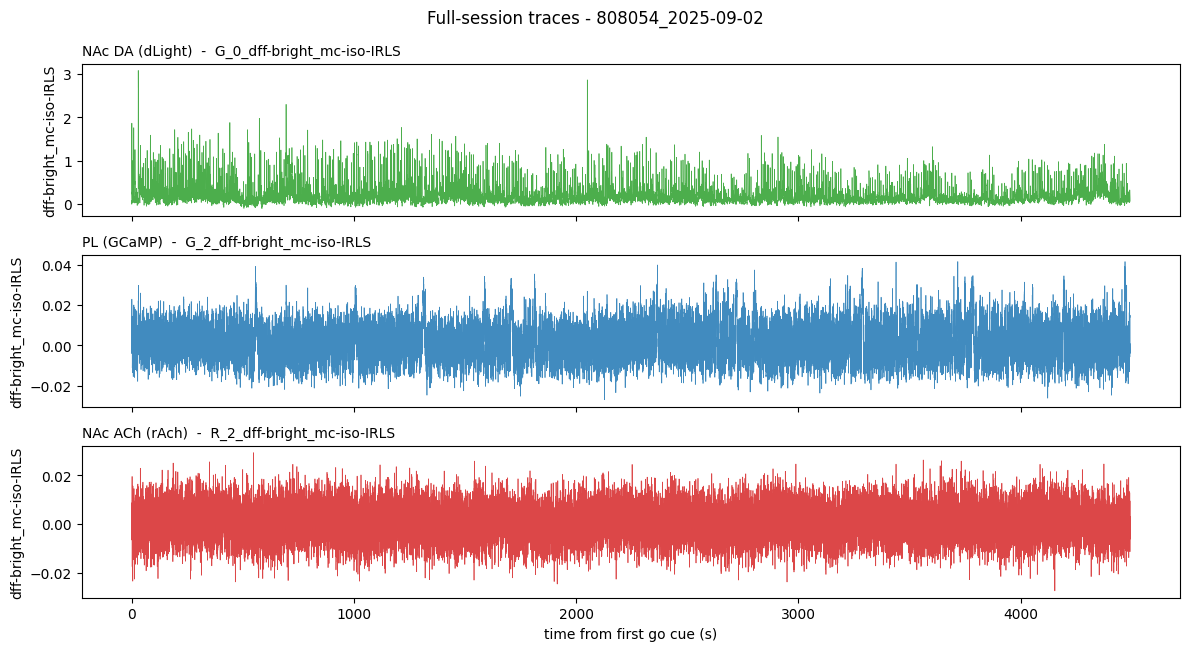

In [38]:
fig, axes = plt.subplots(len(examples), 1, sharex=True, figsize=(12, 2.2 * len(examples)))
for ax, ex in zip(np.atleast_1d(axes), examples):
    t, y = get_trace(df_fip, ex["event"])
    ax.plot(t, y, color=ex["color"], lw=0.5, alpha=0.85)
    ax.set_ylabel(ex["variant"])
    ax.set_title("%s  -  %s" % (ex["label"], ex["event"]), loc="left", fontsize=10)
np.atleast_1d(axes)[-1].set_xlabel("time from first go cue (s)")
fig.suptitle("Full-session traces - %s" % nwb.session_id)
fig.tight_layout()
plt.show()

### 60-second window with go cues

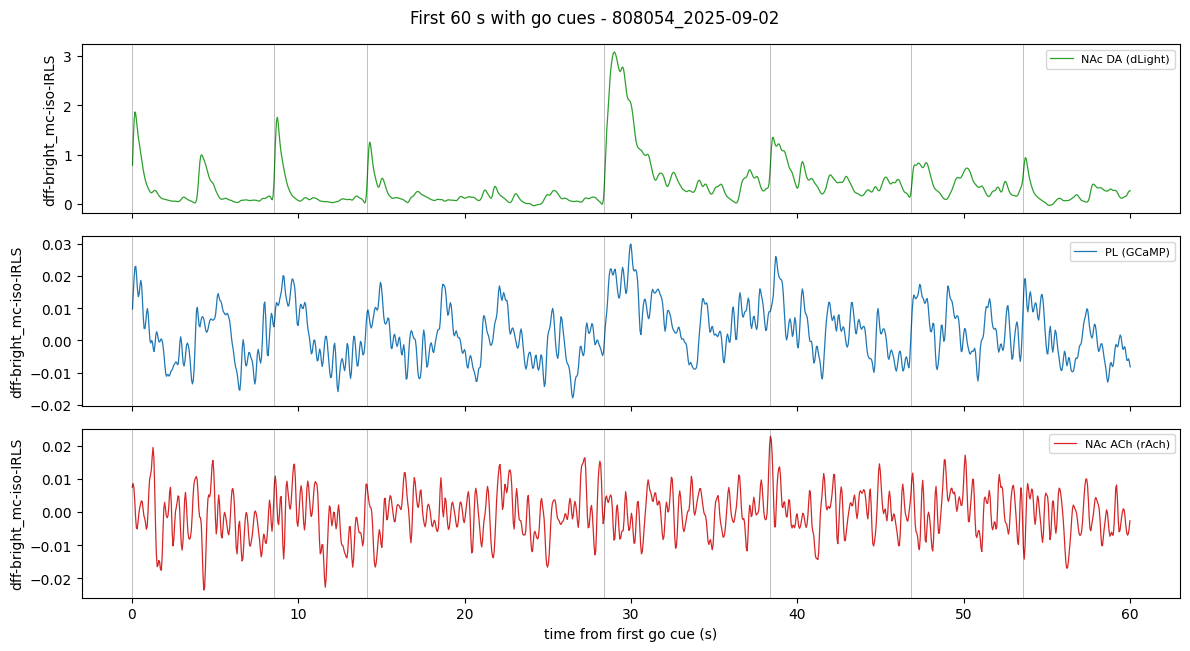

In [39]:
WINDOW = (0, 60)  # seconds from first go cue
cues = None
if cue_col is not None:  # cue_col detected in section 6
    cues = df_trials[cue_col]
    cues = cues[(cues >= WINDOW[0]) & (cues <= WINDOW[1])].to_numpy()

fig, axes = plt.subplots(len(examples), 1, sharex=True, figsize=(12, 2.2 * len(examples)))
for ax, ex in zip(np.atleast_1d(axes), examples):
    t, y = get_trace(df_fip, ex["event"])
    m = (t >= WINDOW[0]) & (t <= WINDOW[1])
    ax.plot(t[m], y[m], color=ex["color"], lw=0.9, label=ex["label"])
    if cues is not None:
        for c in cues:
            ax.axvline(c, color="k", lw=0.5, alpha=0.35)
    ax.set_ylabel(ex["variant"])
    ax.legend(loc="upper right", fontsize=8)
np.atleast_1d(axes)[-1].set_xlabel("time from first go cue (s)")
fig.suptitle("First %d s with go cues - %s" % (WINDOW[1], nwb.session_id))
fig.tight_layout()
plt.show()

### Peri-go-cue averages (native dff)

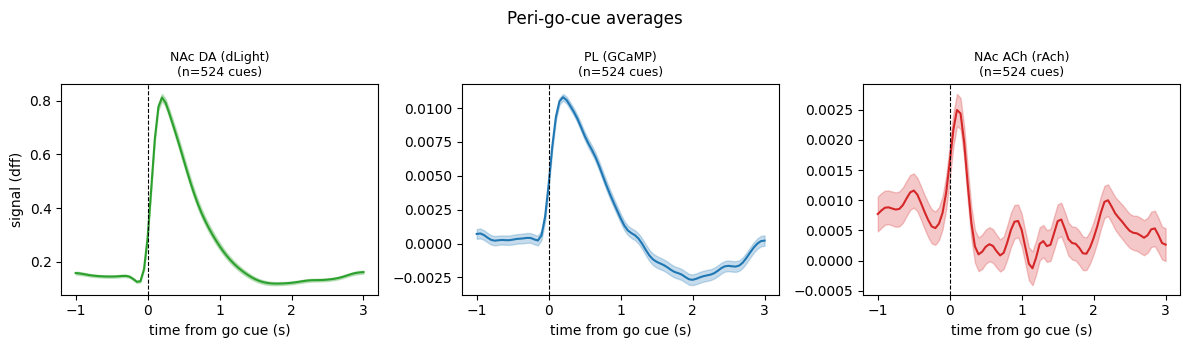

In [40]:
fig, axes = plt.subplots(1, len(examples), figsize=(4 * len(examples), 3.5))
for ax, ex in zip(np.atleast_1d(axes), examples):
    etr = peri_event(*get_trace(df_fip, ex["event"]), go_cues, t_before=1.0, t_after=3.0)
    agg = etr.groupby("time")["data"].agg(["mean", "sem"]).reset_index()
    ax.plot(agg["time"], agg["mean"], color=ex["color"])
    ax.fill_between(agg["time"], agg["mean"] - agg["sem"], agg["mean"] + agg["sem"],
                    color=ex["color"], alpha=0.25)
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.set_title("%s\n(n=%d cues)" % (ex["label"], etr["event_number"].nunique()), fontsize=9)
    ax.set_xlabel("time from go cue (s)")
np.atleast_1d(axes)[0].set_ylabel("signal (dff)")
fig.suptitle("Peri-go-cue averages")
fig.tight_layout()
plt.show()

### Z-scored motion energy & movement onsets

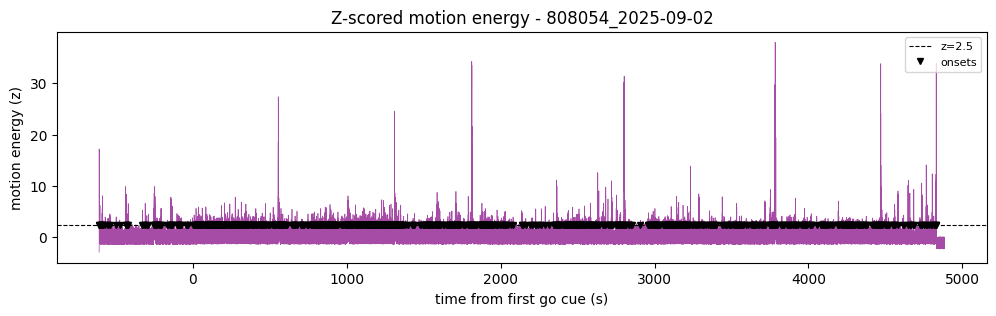

In [41]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_me, me_z, color="purple", lw=0.5, alpha=0.7)
ax.axhline(Z_THRESH, color="k", ls="--", lw=0.8, label="z=%.1f" % Z_THRESH)
ax.plot(me_onset_times, np.full(len(me_onset_times), Z_THRESH), "v", color="k", ms=4,
        label="onsets")
ax.set_xlabel("time from first go cue (s)")
ax.set_ylabel("motion energy (z)")
ax.set_title("Z-scored motion energy - %s" % nwb.session_id)
ax.legend(loc="upper right", fontsize=8)
plt.show()

### FIP aligned to motion-energy onsets

Does each neuromodulator move with gross body movement?

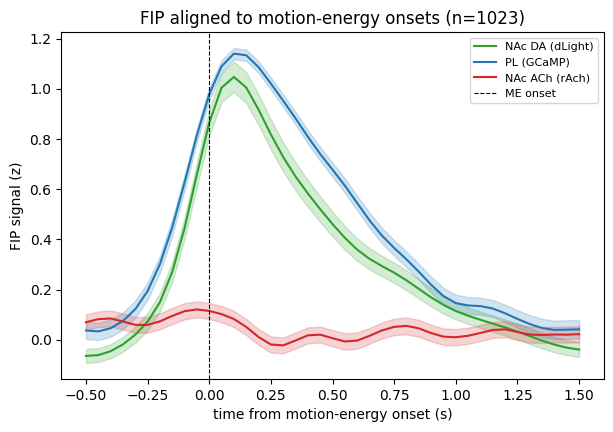

In [42]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for ex in examples:
    t, y = get_trace(df_fip, ex["event"])
    etr = peri_event(t, zscore(y), me_onset_times, t_before=0.5, t_after=1.5, censor=False)
    agg = etr.groupby("time")["data"].agg(["mean", "sem"]).reset_index()
    ax.plot(agg["time"], agg["mean"], color=ex["color"], label=ex["label"])
    ax.fill_between(agg["time"], agg["mean"] - agg["sem"], agg["mean"] + agg["sem"],
                    color=ex["color"], alpha=0.2)
ax.axvline(0, color="k", lw=0.8, ls="--", label="ME onset")
ax.set_xlabel("time from motion-energy onset (s)")
ax.set_ylabel("FIP signal (z)")
ax.set_title("FIP aligned to motion-energy onsets (n=%d)" % len(me_onset_times))
ax.legend(fontsize=8)
plt.show()

### Motion energy aligned to each signal's transients

Reverse direction: a pre-transient rise in ME means movement tends to precede that signal.

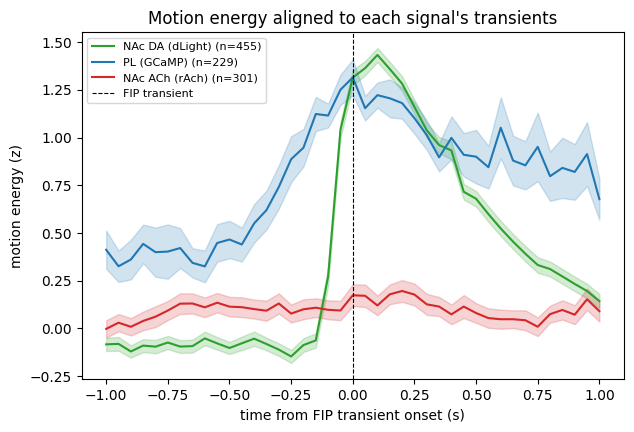

In [43]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for ex in examples:
    t, y = get_trace(df_fip, ex["event"])
    fip_onsets = threshold_onsets(t, y, z_thresh=2.0, refractory=1.0, min_run=3)
    etr = peri_event(t_me, me_z, fip_onsets, t_before=1.0, t_after=1.0, censor=False)
    agg = etr.groupby("time")["data"].agg(["mean", "sem"]).reset_index()
    ax.plot(agg["time"], agg["mean"], color=ex["color"],
            label="%s (n=%d)" % (ex["label"], len(fip_onsets)))
    ax.fill_between(agg["time"], agg["mean"] - agg["sem"], agg["mean"] + agg["sem"],
                    color=ex["color"], alpha=0.2)
ax.axvline(0, color="k", lw=0.8, ls="--", label="FIP transient")
ax.set_xlabel("time from FIP transient onset (s)")
ax.set_ylabel("motion energy (z)")
ax.set_title("Motion energy aligned to each signal's transients")
ax.legend(fontsize=8)
plt.show()

### Cross-correlation: motion energy × FIP

Resample both onto a common 20 Hz grid over their overlap; peak-lag sign shows which leads (positive = motion energy leads FIP).

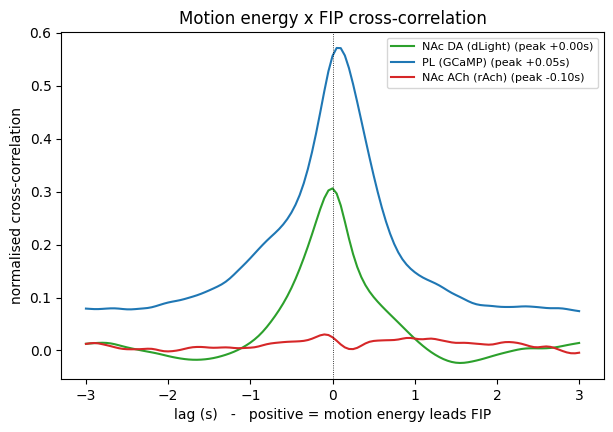

In [44]:
FS_XC = 20      # Hz, common resampling grid
MAXLAG = 3.0    # s

fig, ax = plt.subplots(figsize=(7, 4.5))
for ex in examples:
    t, y = get_trace(df_fip, ex["event"])
    finite = np.isfinite(t) & np.isfinite(y)
    t, y = t[finite], y[finite]
    lo = max(t.min(), t_me.min())
    hi = min(t.max(), t_me.max())
    grid = np.arange(lo, hi, 1.0 / FS_XC)
    fip_i = np.interp(grid, t, y)          # FIP on common grid
    mfin = np.isfinite(t_me) & np.isfinite(me_z)
    me_i = np.interp(grid, t_me[mfin], me_z[mfin])  # ME (z) on common grid (interp only)
    lags, c = norm_xcorr(fip_i, me_i, fs=FS_XC, maxlag=MAXLAG)
    peak = lags[int(np.argmax(c))]
    ax.plot(lags, c, color=ex["color"], label="%s (peak %+.2fs)" % (ex["label"], peak))
ax.axvline(0, color="k", lw=0.6, ls=":")
ax.set_xlabel("lag (s)   -   positive = motion energy leads FIP")
ax.set_ylabel("normalised cross-correlation")
ax.set_title("Motion energy x FIP cross-correlation")
ax.legend(fontsize=8)
plt.show()

## Multi-session comparison

Everything above runs on one session (`SESSION_IDX`). This section reruns that pipeline over
**all curated sessions** and compares FIP ↔ motion-energy coupling across them. The same
single-session helpers (`peri_event`, `motion_energy_to_session`, `threshold_onsets`,
`get_trace`) are reused inside a session loop; results are pooled with **session as the sampling
unit** (per-session mean → mean ± SEM), grouped by **region × subject**.

Four analyses:

1. **ETR of FIP from ME** — FIP aligned to motion-energy onsets.
2. **ETR of ME from FIP** — motion energy aligned to FIP transients.
3. **Within-trial (0–2 s) vs ITI (2–4 s)** relative to go cue.
4. **Consecutive rewards / failures** — peri-go-cue responses binned by `num_reward_past`
   (from `rachel_analysis_utils.analysis_utils.enrich_df_trials`).

Motion energy is reused as a first-class signal: it can be injected into each `df_fip` as a
pseudo-channel (`event="ME"`), which the upstream `plot_fip` PSTH machinery treats like any FIP
channel (see the optional cell at the end). The analyses below use a lighter, self-contained
SEM-across-sessions path.

In [45]:
# === Multi-session helpers ===
# Reuse the single-session primitives defined above (parse_event, get_trace, peri_event,
# zscore, threshold_onsets, motion_energy_to_session, ALIGN_COL, EXAMPLE_SPECS).
# NB: we DON'T import rachel_analysis_utils.analysis_utils — that module doesn't parse on
# Python 3.9 (a nested-quote f-string at analysis_utils.py:294; the package targets >=3.10).
# We only need its `num_reward_past`, reimplemented 3.9-safe below in `enrich_streaks`.


def build_meta(df_fip):
    """Signal table for one session's df_fip (pearsonR excluded; region from curation)."""
    evs = [e for e in sorted(df_fip["event"].unique()) if "pearson" not in e.lower()]
    meta = pd.DataFrame([(e,) + parse_event(e) for e in evs],
                        columns=["event", "channel", "fiber", "variant"])
    if "intended_measurement" in df_fip.columns:
        ev2region = (df_fip.dropna(subset=["intended_measurement"])
                     .groupby("event")["intended_measurement"]
                     .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else None))
        meta["region"] = meta["event"].map(ev2region)
    return meta


def enrich_streaks(df_trials):
    """Add `num_reward_past` to df_trials (3.9-safe reimplementation of the reward part of
    rachel_analysis_utils.analysis_utils.enrich_df_trials, whose module won't import on 3.9).
    num_reward_past = run length of consecutive rewarded trials (positive) or consecutive
    unrewarded trials (negative), per session. Returns df unchanged if reward columns absent."""
    df = df_trials
    if "earned_reward" not in df.columns:
        return df  # streak bins stay off for this session
    extra = df["extra_reward"] if "extra_reward" in df.columns else 0
    reward_all = df["earned_reward"].astype(float) + (
        extra if np.isscalar(extra) else extra.astype(float))
    df["reward_all"] = reward_all
    if "ses_idx" in df.columns:
        prev = reward_all.groupby(df["ses_idx"]).shift(1)
    else:
        prev = reward_all.shift(1)
    df["rewarded_prev"] = prev
    run_id = (prev != reward_all).cumsum()                 # new id each time reward state flips
    num = df.groupby(run_id).cumcount() + 1                # 1-indexed position within the run
    df["num_reward_past"] = num.where(reward_all != 0, -num)  # negate runs of no-reward
    return df


def locate_me_assets(session_id, data_root="/root/capsule/data"):
    """(video_csv, me_path) for a session; raises FileNotFoundError if either is missing."""
    subject, date = session_id.split("_")[:2]
    beh = [d for d in sorted(glob.glob(os.path.join(data_root, "behavior_%s_%s_*" % (subject, date))))
           if "motionenergy" not in d]
    if not beh:
        raise FileNotFoundError("no behavior-video asset for %s_%s" % (subject, date))
    video_csv = os.path.join(beh[0], "behavior-videos", "bottom_camera.csv")
    if not os.path.exists(video_csv):
        raise FileNotFoundError("missing %s" % video_csv)
    me_dirs = sorted(glob.glob(os.path.join(data_root,
                     "behavior_%s_%s_*motionenergy*" % (subject, date))))
    if not me_dirs:
        raise FileNotFoundError("no motion-energy asset for %s_%s" % (subject, date))
    hits = glob.glob(os.path.join(me_dirs[0], "**", "bottom_camera_motion_energy_clean.npy"),
                     recursive=True)
    if not hits:
        raise FileNotFoundError("me .npy not found under %s" % me_dirs[0])
    return video_csv, hits[0]


def attach_me_to_df_fip(df_fip, t_me, me_z, ses_idx, event_name="ME"):
    """Append motion energy to df_fip as a pseudo-channel (event='ME') so the upstream
    plot_fip PSTH functions, which select a signal via df_fip['event'] == channel, can use it
    exactly like a FIP channel."""
    me_rows = pd.DataFrame({"timestamps": np.asarray(t_me, float),
                            "data": np.asarray(me_z, float),
                            "event": event_name,
                            "intended_measurement": "motion_energy",
                            "ses_idx": ses_idx})
    return pd.concat([df_fip, me_rows], ignore_index=True)


def process_session(nwb, data_root="/root/capsule/data"):
    """Single-session pipeline -> dict for the cross-session analyses. Raises (caller skips) if
    df_trials or the ME/video assets are missing. Mirrors the single-session cells above."""
    df_trials = getattr(nwb, "df_trials", None)
    if df_trials is None or ALIGN_COL not in df_trials.columns:
        raise ValueError("missing df_trials / %s" % ALIGN_COL)
    try:
        df_trials_enr = enrich_streaks(df_trials.copy())  # adds num_reward_past
    except Exception as e:
        print("  [%s] enrich_streaks failed (%s); streak bins off for this session"
              % (nwb.session_id, type(e).__name__))
        df_trials_enr = df_trials
    video_csv, me_path = locate_me_assets(nwb.session_id, data_root)
    t_me, me, offset = motion_energy_to_session(me_path, video_csv, nwb.df_trials)
    me_z = zscore(me)
    me_onsets = threshold_onsets(t_me, me, z_thresh=2.5, refractory=0.5, min_run=3)
    return {"session_id": nwb.session_id, "subject_id": nwb.session_id.split("_")[0],
            "nwb": nwb, "df_fip": nwb.df_fip, "df_trials": df_trials_enr,
            "meta": build_meta(nwb.df_fip), "t_me": t_me, "me": me, "me_z": me_z,
            "me_onsets": me_onsets, "go_cues": df_trials_enr[ALIGN_COL].dropna().to_numpy()}


# --- cross-session aggregation helpers (session = sampling unit) ---
def session_etr_mean(t, y, event_times, t_before, t_after, censor, censor_times=None):
    """Per-session mean trace across events -> Series indexed by relative time (or None)."""
    if len(np.asarray(event_times)) == 0 or len(np.asarray(t)) == 0:
        return None
    etr = peri_event(t, y, event_times, t_before=t_before, t_after=t_after,
                     censor=censor, censor_times=censor_times)
    if etr is None or etr.empty:
        return None
    return etr.groupby("time")["data"].mean()


def aggregate_series(series_list):
    """mean +/- SEM across a list of per-session Series sharing the ETR time grid -> (mean, sem, n)."""
    series_list = [s for s in series_list if s is not None]
    if not series_list:
        return None
    M = pd.concat(series_list, axis=1)
    return M.mean(axis=1), M.sem(axis=1), M.shape[1]


def window_mean(series, lo, hi):
    """Mean of a time-indexed Series over [lo, hi) seconds (NaN-safe)."""
    idx = series.index.to_numpy(float)
    m = (idx >= lo) & (idx < hi)
    return float(np.nanmean(series.values[m])) if m.any() else np.nan


def iter_region_signals(sessions, region_substr):
    """Yield (session_dict, event) for every FIP series whose region matches, across sessions."""
    for s in sessions:
        meta = s["meta"]
        if "region" not in meta.columns:
            continue
        hit = meta[meta["region"].fillna("").str.contains(region_substr, case=False)]
        for ev in hit["event"]:
            yield s, ev


def collect_region_etr(sessions, region_substr, signal_kind, event_kind,
                       t_before, t_after, censor, fip_onset_kw=None, censor_all_go=False):
    """Per-session mean ETR records for one region.
    signal_kind: 'fip' (matched FIP trace, z-scored) or 'me' (motion energy, z).
    event_kind:  'me_onsets' | 'fip_onsets' | 'go_cues'.
    Returns a list of dicts {subject, session, event, series, n_events}."""
    recs = []
    for s, ev in iter_region_signals(sessions, region_substr):
        t_fip, y_fip = get_trace(s["df_fip"], ev)
        ctimes = None
        if event_kind == "me_onsets":
            events = s["me_onsets"]
        elif event_kind == "fip_onsets":
            events = threshold_onsets(t_fip, y_fip, **(fip_onset_kw or {}))
        elif event_kind == "go_cues":
            events = s["go_cues"]
            if censor_all_go:
                ctimes = s["go_cues"]
        else:
            continue
        if signal_kind == "fip":
            t, y = t_fip, zscore(y_fip)
        else:
            t, y = s["t_me"], s["me_z"]
        ser = session_etr_mean(t, y, events, t_before, t_after, censor, censor_times=ctimes)
        if ser is not None:
            recs.append({"subject": s["subject_id"], "session": s["session_id"], "event": ev,
                         "series": ser, "n_events": int(len(np.asarray(events)))})
    return recs


def plot_by_subject(ax, recs, color, label=None, show_subjects=True):
    """Thin line per subject (mean of its sessions) + bold across-subject mean +/- SEM.
    Returns the number of subjects contributing."""
    by_subj = {}
    for r in recs:
        by_subj.setdefault(r["subject"], []).append(r["series"])
    subj_means = []
    for subj in sorted(by_subj):
        m = pd.concat(by_subj[subj], axis=1).mean(axis=1)
        subj_means.append(m)
        if show_subjects:
            ax.plot(m.index, m.values, color=color, lw=0.6, alpha=0.25)
    if not subj_means:
        return 0
    M = pd.concat(subj_means, axis=1)
    grand, sem = M.mean(axis=1), M.sem(axis=1)
    ax.plot(grand.index, grand.values, color=color, lw=2.2, label=label)
    ax.fill_between(grand.index, (grand - sem).values, (grand + sem).values,
                    color=color, alpha=0.2)
    return M.shape[1]


# Reward/failure streak bins from num_reward_past
# (positive = consecutive rewards, negative = consecutive failures).
STREAK_BINS = [("fail>=3", lambda v: v <= -3, "#08519c"),
               ("fail2",   lambda v: v == -2, "#3182bd"),
               ("fail1",   lambda v: v == -1, "#6baed6"),
               ("rew1",    lambda v: v == 1,  "#fdae6b"),
               ("rew2",    lambda v: v == 2,  "#fd8d3c"),
               ("rew>=3",  lambda v: v >= 3,  "#e6550d")]


def streak_go_cues(df_trials, bin_fn):
    """Go-cue times (session clock) for trials whose num_reward_past satisfies bin_fn."""
    if "num_reward_past" not in df_trials.columns:
        return None
    sub = df_trials.dropna(subset=[ALIGN_COL, "num_reward_past"])
    mask = sub["num_reward_past"].map(bin_fn).astype(bool)
    return sub.loc[mask, ALIGN_COL].to_numpy()

In [46]:
# Run the single-session pipeline over every curated session. Sessions whose ME/video assets
# are missing (or whose trials lack the alignment column) are skipped and logged, not fatal.
sessions = []
skipped = []
for nwb_i in nwb_list:
    try:
        sessions.append(process_session(nwb_i))
    except Exception as e:
        skipped.append((nwb_i.session_id, "%s: %s" % (type(e).__name__, e)))

print("Usable ME in %d / %d curated sessions (%d skipped)."
      % (len(sessions), len(nwb_list), len(skipped)))
subjects = sorted(set(s["subject_id"] for s in sessions))
print("Subjects with data: %d -> %s" % (len(subjects), subjects))
if skipped:
    print("\nSkipped (first 25):")
    for sid, why in skipped[:25]:
        print("  %-22s %s" % (sid, why))

Usable ME in 10 / 172 curated sessions (162 skipped).
Subjects with data: 1 -> ['808054']

Skipped (first 25):
  808054_2025-09-16      FileNotFoundError: no behavior-video asset for 808054_2025-09-16
  808054_2025-09-17      FileNotFoundError: no behavior-video asset for 808054_2025-09-17
  808054_2025-09-18      FileNotFoundError: no behavior-video asset for 808054_2025-09-18
  808054_2025-09-19      FileNotFoundError: no behavior-video asset for 808054_2025-09-19
  808054_2025-09-22      FileNotFoundError: no behavior-video asset for 808054_2025-09-22
  808054_2025-09-23      FileNotFoundError: no behavior-video asset for 808054_2025-09-23
  808054_2025-09-24      FileNotFoundError: no behavior-video asset for 808054_2025-09-24
  808054_2025-09-25      FileNotFoundError: no behavior-video asset for 808054_2025-09-25
  808054_2025-09-26      FileNotFoundError: no behavior-video asset for 808054_2025-09-26
  808054_2025-10-02      FileNotFoundError: no behavior-video asset for 808054_

### Analysis 1 — FIP aligned to motion-energy onsets (ETR of FIP from ME)

The single-session "FIP aligned to ME onsets" plot, now pooled across sessions. For each region,
a thin line per subject (mean of its sessions) and a bold across-subject mean ± SEM band.

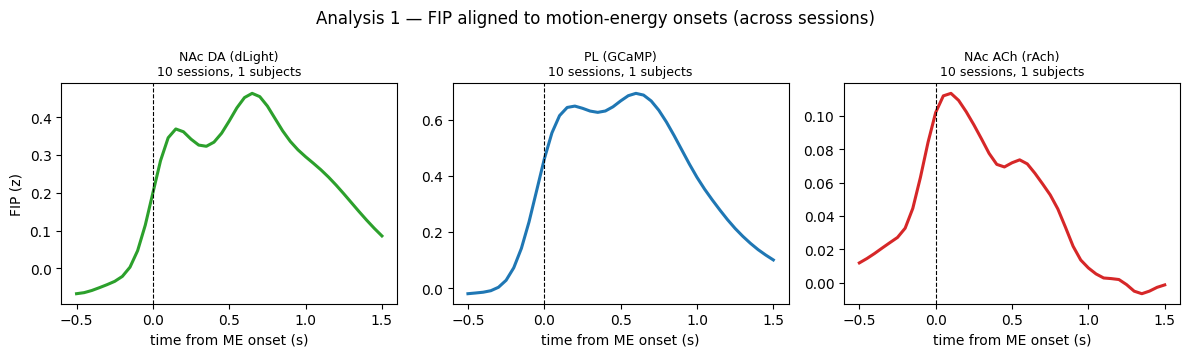

res_fip_from_me: (49, 6)


In [47]:
# Analysis 1 — FIP (z) aligned to motion-energy onsets, across sessions.
# Per session, align each region's FIP trace to that session's ME onsets and average; then a
# thin line per subject (mean of its sessions) and a bold across-subject mean ± SEM. One panel
# per region.
res_fip_from_me = []
fig, axes = plt.subplots(1, len(EXAMPLE_SPECS), figsize=(4 * len(EXAMPLE_SPECS), 3.6),
                         sharex=True)
for ax, (label, substr, color) in zip(np.atleast_1d(axes), EXAMPLE_SPECS):
    recs = collect_region_etr(sessions, substr, signal_kind="fip", event_kind="me_onsets",
                              t_before=0.5, t_after=1.5, censor=False)
    n_subj = plot_by_subject(ax, recs, color, label)
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.set_title("%s\n%d sessions, %d subjects"
                 % (label, len(set(r["session"] for r in recs)), n_subj), fontsize=9)
    ax.set_xlabel("time from ME onset (s)")
    for r in recs:
        res_fip_from_me.append({"region": substr, "subject": r["subject"],
                                "session": r["session"], "condition": "all",
                                "amp_0_1s": window_mean(r["series"], 0.0, 1.0),
                                "n_events": r["n_events"]})
np.atleast_1d(axes)[0].set_ylabel("FIP (z)")
fig.suptitle("Analysis 1 — FIP aligned to motion-energy onsets (across sessions)")
fig.tight_layout()
plt.show()
res_fip_from_me = pd.DataFrame(res_fip_from_me)
print("res_fip_from_me:", res_fip_from_me.shape)

### Analysis 2 — Motion energy aligned to FIP transients (ETR of ME from FIP)

The reverse direction: detect each region's FIP transients per session and align motion energy
to them. A pre-transient rise in ME means movement tends to precede that signal. Averaged per
session, then mean ± SEM across subjects/sessions.

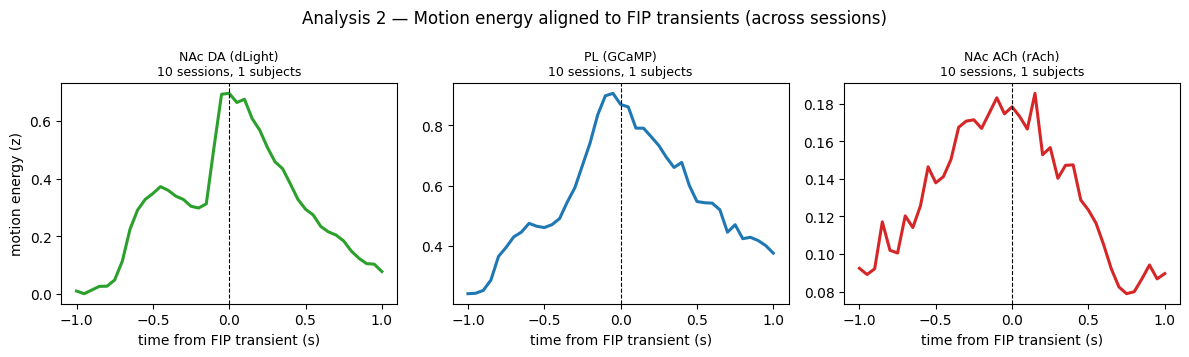

res_me_from_fip: (49, 7)


In [48]:
# Analysis 2 — motion energy aligned to each region's FIP transients (reverse direction).
# Per session, detect FIP transients (threshold_onsets) on the region's trace and align ME (z)
# to them; average per session, then mean ± SEM across subjects/sessions. One panel per region.
res_me_from_fip = []
fig, axes = plt.subplots(1, len(EXAMPLE_SPECS), figsize=(4 * len(EXAMPLE_SPECS), 3.6),
                         sharex=True)
for ax, (label, substr, color) in zip(np.atleast_1d(axes), EXAMPLE_SPECS):
    recs = collect_region_etr(sessions, substr, signal_kind="me", event_kind="fip_onsets",
                              t_before=1.0, t_after=1.0, censor=False,
                              fip_onset_kw=dict(z_thresh=2.0, refractory=1.0, min_run=3))
    n_subj = plot_by_subject(ax, recs, color, label)
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.set_title("%s\n%d sessions, %d subjects"
                 % (label, len(set(r["session"] for r in recs)), n_subj), fontsize=9)
    ax.set_xlabel("time from FIP transient (s)")
    for r in recs:
        res_me_from_fip.append({"region": substr, "subject": r["subject"],
                                "session": r["session"], "condition": "all",
                                "amp_pre": window_mean(r["series"], -0.5, 0.0),
                                "amp_post": window_mean(r["series"], 0.0, 0.5),
                                "n_events": r["n_events"]})
np.atleast_1d(axes)[0].set_ylabel("motion energy (z)")
fig.suptitle("Analysis 2 — Motion energy aligned to FIP transients (across sessions)")
fig.tight_layout()
plt.show()
res_me_from_fip = pd.DataFrame(res_me_from_fip)
print("res_me_from_fip:", res_me_from_fip.shape)

### Analysis 3 — Within-trial (0–2 s) vs ITI (2–4 s) relative to go cue

Aligned to the go cue, the first 2 s is the within-trial response epoch and 2–4 s is treated as
the inter-trial interval. Compare each signal's mean level (and motion energy) between the two
windows, pooled across sessions. Go-cue ETRs are censored against all go cues so adjacent trials
don't leak across the window boundary.

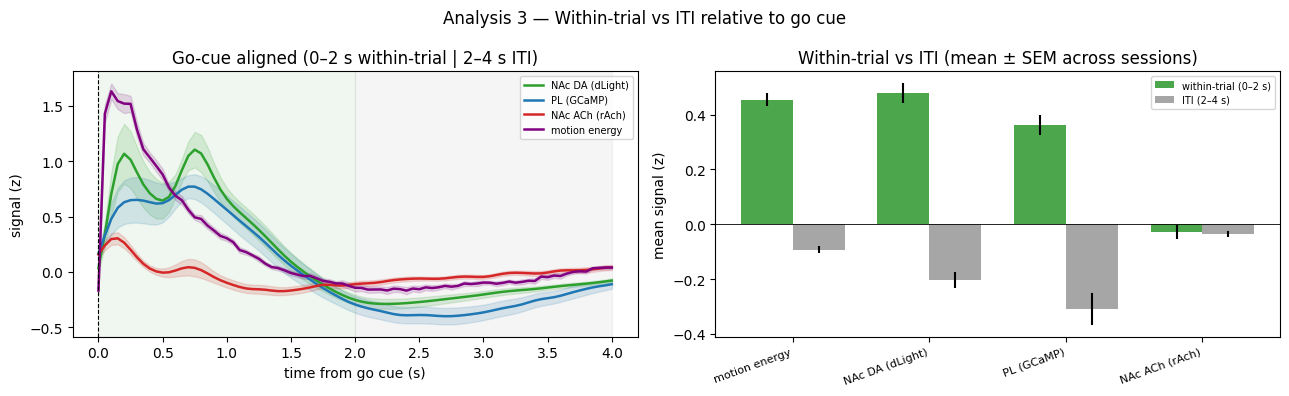

res_trial_iti: (59, 6)


In [49]:
# Analysis 3 — within-trial (0–2 s) vs ITI (2–4 s) relative to go cue.
# Each signal is averaged peri-go-cue over a 0–4 s window (censored against all go cues), then
# split into a within-trial window (0–2 s) and an ITI window (2–4 s). Left: across-session
# grand-mean traces with the two windows shaded. Right: within-trial vs ITI means (±SEM across
# sessions) per signal.
res_trial_iti = []
agg_for_plot = {}  # signal label -> (grand, sem, color)

for label, substr, color in EXAMPLE_SPECS:  # FIP regions
    recs = collect_region_etr(sessions, substr, signal_kind="fip", event_kind="go_cues",
                              t_before=0.0, t_after=4.0, censor=True, censor_all_go=True)
    a = aggregate_series([r["series"] for r in recs])
    if a is not None:
        agg_for_plot[label] = (a[0], a[1], color)
    for r in recs:
        res_trial_iti.append({"signal": label, "region": substr, "subject": r["subject"],
                              "session": r["session"],
                              "within_trial": window_mean(r["series"], 0.0, 2.0),
                              "iti": window_mean(r["series"], 2.0, 4.0)})

me_sers = []  # motion energy aligned to go cues
for s in sessions:
    ser = session_etr_mean(s["t_me"], s["me_z"], s["go_cues"], 0.0, 4.0, True,
                           censor_times=s["go_cues"])
    if ser is None:
        continue
    me_sers.append(ser)
    res_trial_iti.append({"signal": "motion energy", "region": "ME", "subject": s["subject_id"],
                          "session": s["session_id"],
                          "within_trial": window_mean(ser, 0.0, 2.0),
                          "iti": window_mean(ser, 2.0, 4.0)})
a = aggregate_series(me_sers)
if a is not None:
    agg_for_plot["motion energy"] = (a[0], a[1], "purple")
res_trial_iti = pd.DataFrame(res_trial_iti)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4))
for label, (grand, sem, color) in agg_for_plot.items():
    axL.plot(grand.index, grand.values, color=color, lw=1.8, label=label)
    axL.fill_between(grand.index, (grand - sem).values, (grand + sem).values,
                     color=color, alpha=0.15)
axL.axvspan(0, 2, color="green", alpha=0.06)
axL.axvspan(2, 4, color="gray", alpha=0.08)
axL.axvline(0, color="k", lw=0.8, ls="--")
axL.set_xlabel("time from go cue (s)")
axL.set_ylabel("signal (z)")
axL.set_title("Go-cue aligned (0–2 s within-trial | 2–4 s ITI)")
axL.legend(fontsize=7)

sig_order = [l for l in ["motion energy"] + [e[0] for e in EXAMPLE_SPECS]
             if l in set(res_trial_iti["signal"])]
x = np.arange(len(sig_order))
w = 0.38
wt_m = [res_trial_iti.loc[res_trial_iti.signal == s, "within_trial"].mean() for s in sig_order]
wt_e = [res_trial_iti.loc[res_trial_iti.signal == s, "within_trial"].sem() for s in sig_order]
it_m = [res_trial_iti.loc[res_trial_iti.signal == s, "iti"].mean() for s in sig_order]
it_e = [res_trial_iti.loc[res_trial_iti.signal == s, "iti"].sem() for s in sig_order]
axR.bar(x - w / 2, wt_m, w, yerr=wt_e, label="within-trial (0–2 s)", color="green", alpha=0.7)
axR.bar(x + w / 2, it_m, w, yerr=it_e, label="ITI (2–4 s)", color="gray", alpha=0.7)
axR.axhline(0, color="k", lw=0.6)
axR.set_xticks(x)
axR.set_xticklabels(sig_order, rotation=20, ha="right", fontsize=8)
axR.set_ylabel("mean signal (z)")
axR.set_title("Within-trial vs ITI (mean ± SEM across sessions)")
axR.legend(fontsize=7)
fig.suptitle("Analysis 3 — Within-trial vs ITI relative to go cue")
fig.tight_layout()
plt.show()
print("res_trial_iti:", res_trial_iti.shape)

### Analysis 4 — Consecutive rewards / failures

`enrich_df_trials` adds `num_reward_past`: the count of consecutive rewards (positive) or
failures (negative) leading into each trial. Bin go cues by streak and compare the peri-go-cue
FIP response across bins, pooled across sessions. Does the neuromodulator response scale with
recent reward history?

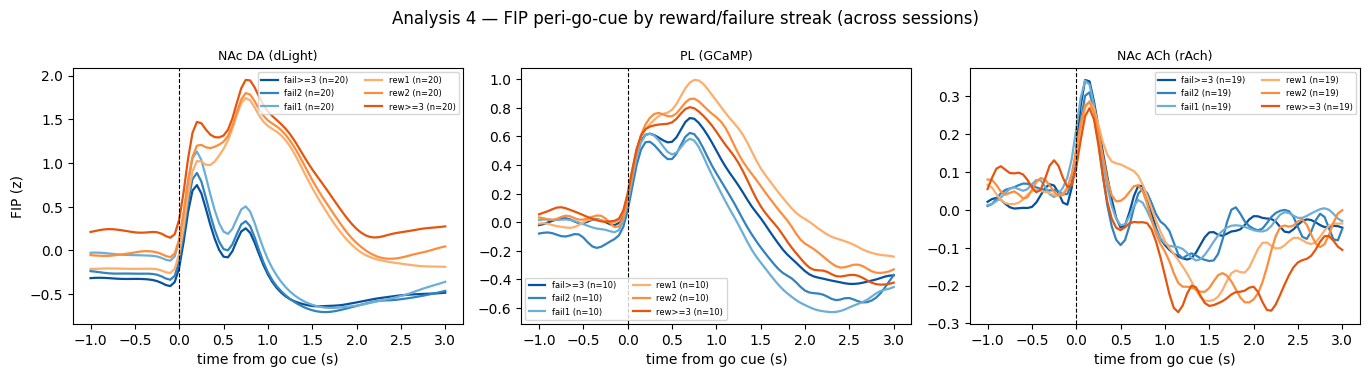

res_streak: (294, 6)


In [50]:
# Analysis 4 — FIP peri-go-cue averages split by reward/failure streak (num_reward_past).
# Go cues are binned by how many consecutive rewards (+) or failures (-) preceded the trial;
# each bin's go cues drive a peri-event average, censored against ALL go cues so neighbouring
# trials don't bleed in. One panel per region; one line per streak bin (across-session mean).
res_streak = []
fig, axes = plt.subplots(1, len(EXAMPLE_SPECS), figsize=(4.6 * len(EXAMPLE_SPECS), 3.8),
                         sharex=True)
for ax, (label, substr, color) in zip(np.atleast_1d(axes), EXAMPLE_SPECS):
    for bin_label, bin_fn, bcolor in STREAK_BINS:
        sers = []
        for s, ev in iter_region_signals(sessions, substr):
            ev_times = streak_go_cues(s["df_trials"], bin_fn)
            if ev_times is None or len(ev_times) == 0:
                continue
            t, y = get_trace(s["df_fip"], ev)
            ser = session_etr_mean(t, zscore(y), ev_times, 1.0, 3.0, True,
                                   censor_times=s["go_cues"])
            if ser is not None:
                sers.append(ser)
                res_streak.append({"region": substr, "subject": s["subject_id"],
                                   "session": s["session_id"], "condition": bin_label,
                                   "n_events": int(len(ev_times)),
                                   "amp_0_1s": window_mean(ser, 0.0, 1.0)})
        agg = aggregate_series(sers)
        if agg is None:
            continue
        grand, sem, n = agg
        ax.plot(grand.index, grand.values, color=bcolor, lw=1.6,
                label="%s (n=%d)" % (bin_label, n))
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("time from go cue (s)")
    ax.legend(fontsize=6, ncol=2)
np.atleast_1d(axes)[0].set_ylabel("FIP (z)")
fig.suptitle("Analysis 4 — FIP peri-go-cue by reward/failure streak (across sessions)")
fig.tight_layout()
plt.show()
res_streak = pd.DataFrame(res_streak)
print("res_streak:", res_streak.shape)

### Cross-session results table

Collect the per-analysis scalar summaries (`res_*` DataFrames) into a single tidy
`df_results`, one row per (session, region/signal, analysis, condition). Kept in memory — no
new cached intermediates.

In [51]:
# Pool the per-analysis scalar summaries into one tidy table (in-memory; session is the
# sampling unit). Schemas differ per analysis, so columns are unioned (NaN where N/A).
_tables = {"fip_from_me": globals().get("res_fip_from_me"),
           "me_from_fip": globals().get("res_me_from_fip"),
           "trial_vs_iti": globals().get("res_trial_iti"),
           "streak": globals().get("res_streak")}
parts = []
for _name, _obj in _tables.items():
    if isinstance(_obj, pd.DataFrame) and not _obj.empty:
        print("%-13s %s" % (_name, tuple(_obj.shape)))
        parts.append(_obj.assign(table=_name))
df_results = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
print("df_results:", df_results.shape)
df_results.head()

fip_from_me   (49, 6)
me_from_fip   (49, 7)
trial_vs_iti  (59, 6)
streak        (294, 6)
df_results: (451, 12)


,region,subject,session,condition,amp_0_1s,n_events,table,amp_pre,amp_post,signal,within_trial,iti
0,dLight,808054,808054_2025-09-02,all,0.549610,1023.0,fip_from_me,NaN,NaN,NaN,NaN,NaN
1,dLight,808054,808054_2025-09-02,all,0.568417,1023.0,fip_from_me,NaN,NaN,NaN,NaN,NaN
2,dLight,808054,808054_2025-09-03,all,0.087234,1155.0,fip_from_me,NaN,NaN,NaN,NaN,NaN
3,dLight,808054,808054_2025-09-03,all,0.073196,1155.0,fip_from_me,NaN,NaN,NaN,NaN,NaN
4,dLight,808054,808054_2025-09-04,all,0.293040,1270.0,fip_from_me,NaN,NaN,NaN,NaN,NaN


### (Optional) ME as a FIP pseudo-channel for the upstream PSTH machinery

The analyses above use a self-contained SEM-across-sessions path. If you instead want the
upstream hierarchical-bootstrap PSTH plots (`aind_dynamic_foraging_basic_analysis.plot.plot_fip`),
set `BUILD_NWB_LIST_ME=True` below to inject motion energy into each `df_fip` as a channel
named `"ME"`. Those functions select a signal by `df_fip["event"] == channel`, so once ME is a
channel it is treated exactly like a FIP signal.

In [52]:
# Optional: inject ME as a FIP pseudo-channel (event='ME') so the upstream multi-session
# PSTH machinery (aind_dynamic_foraging_basic_analysis.plot.plot_fip) can treat motion
# energy exactly like a FIP channel — it selects signals via df_fip['event'] == channel, so
# 'ME' becomes usable by plot_fip_psth_compare_alignments / _compare_channels /
# fip_psth_multiple_inner_compute (incl. their hierarchical-bootstrap error bars).
# Off by default: it appends ME rows to every session's df_fip (memory). The analyses above
# use the lighter in-notebook SEM-across-sessions path and do not need this.
BUILD_NWB_LIST_ME = False

if BUILD_NWB_LIST_ME:
    nwb_list_me = []
    for s in sessions:
        nwb_i = s["nwb"]
        nwb_i.df_fip = attach_me_to_df_fip(nwb_i.df_fip, s["t_me"], s["me_z"], nwb_i.session_id)
        nwb_i.df_trials = s["df_trials"]
        nwb_list_me.append(nwb_i)
    print("nwb_list_me ready (%d sessions); 'ME' is now a channel in df_fip." % len(nwb_list_me))
    print("e.g. from aind_dynamic_foraging_basic_analysis.plot import plot_fip")
    print("     plot_fip.fip_psth_multiple_inner_compute(nwb_list_me, me_onsets_list, "
          "channel='G_0_dff-bright_mc-iso-IRLS', average=True, tw=[-0.5, 1.5], censor=False)")
else:
    print("BUILD_NWB_LIST_ME=False — using the in-notebook SEM-across-sessions path.")

BUILD_NWB_LIST_ME=False — using the in-notebook SEM-across-sessions path.
